In [1]:
import numpy as np # trabalhar com array multi-dimensional homogeneo
import pandas as pd # trabalhar com Dataframe
import matplotlib.pyplot as plt # visualização dos dados
import sweetviz as sv
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Ocorrências

In [2]:
import pandas as pd

# Opção direta (geralmente funciona)
ocorrencias = pd.read_csv(
    "OCORRENCIA.csv",
    sep=";",                # delimitador é ;
    encoding="latin1",      # ou "cp1252"
    low_memory=False
)
print(ocorrencias.shape)

(13185, 22)


In [3]:
ocorrencias.head(2)

,codigo_ocorrencia,codigo_ocorrencia1,codigo_ocorrencia2,codigo_ocorrencia3,codigo_ocorrencia4,ocorrencia_classificacao,ocorrencia_latitude,ocorrencia_longitude,ocorrencia_cidade,ocorrencia_uf,...,ocorrencia_dia,ocorrencia_hora,investigacao_aeronave_liberada,investigacao_status,divulgacao_relatorio_numero,divulgacao_relatorio_publicado,divulgacao_dia_publicacao,total_recomendacoes,total_aeronaves_envolvidas,ocorrencia_saida_pista
0,87125,87125,87125,87125,87125,INCIDENTE,-7.219166666666,-39.26944444444,JUAZEIRO DO NORTE,CE,...,11/05/2025,04:20:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO
1,87124,87124,87124,87124,87124,INCIDENTE,-18.88361111111,-48.22527777777,UBERLÂNDIA,MG,...,08/05/2025,14:00:00,SIM,FINALIZADA,***,NÃO,NaN,0,1,NÃO


In [4]:
ocorrencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13185 entries, 0 to 13184
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   codigo_ocorrencia               13185 non-null  int64 
 1   codigo_ocorrencia1              13185 non-null  int64 
 2   codigo_ocorrencia2              13185 non-null  int64 
 3   codigo_ocorrencia3              13185 non-null  int64 
 4   codigo_ocorrencia4              13185 non-null  int64 
 5   ocorrencia_classificacao        13185 non-null  object
 6   ocorrencia_latitude             10425 non-null  object
 7   ocorrencia_longitude            10425 non-null  object
 8   ocorrencia_cidade               13185 non-null  object
 9   ocorrencia_uf                   13185 non-null  object
 10  ocorrencia_pais                 13185 non-null  object
 11  ocorrencia_aerodromo            13185 non-null  object
 12  ocorrencia_dia                  13185 non-null

In [5]:
'''
Observa-se um desbalanceamento entre as classes: Incidente 69%, Acidente 21% e incidente Grave 8%, o que pode impactar no desenvolvimento dos modelos.
'''

a = ocorrencias['ocorrencia_classificacao'].value_counts()
a

ocorrencia_classificacao
INCIDENTE          9184
ACIDENTE           2843
INCIDENTE GRAVE    1158
Name: count, dtype: int64

# Recomendação

In [6]:
recomendacao = pd.read_csv(
    "RECOMENDACAO.csv",
    sep=";",                # delimitador é ;
    encoding="latin1",      # ou "cp1252"
    low_memory=False
)
print(recomendacao.shape)

(3388, 9)


In [7]:
recomendacao.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3388 entries, 0 to 3387
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   codigo_ocorrencia4               3387 non-null   object
 1   recomendacao_numero              2890 non-null   object
 2   recomendacao_dia_assinatura      2890 non-null   object
 3   recomendacao_dia_encaminhamento  2890 non-null   object
 4   recomendacao_dia_feedback        2217 non-null   object
 5   recomendacao_conteudo            2889 non-null   object
 6   recomendacao_status              2889 non-null   object
 7   recomendacao_destinatario_sigla  2889 non-null   object
 8   recomendacao_destinatario        2889 non-null   object
dtypes: object(9)
memory usage: 238.3+ KB


# Fator Contribuinte

In [8]:
fator_contribuinte = pd.read_csv(
    "fator_contribuinte.csv",
    sep=";",                # delimitador é ;
    encoding="latin1",      # ou "cp1252"
    low_memory=False
)
print(fator_contribuinte.shape)

(8613, 5)


In [9]:
fator_contribuinte.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8613 entries, 0 to 8612
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   codigo_ocorrencia3   8613 non-null   int64 
 1   fator_nome           8613 non-null   object
 2   fator_aspecto        8613 non-null   object
 3   fator_condicionante  8613 non-null   object
 4   fator_area           8613 non-null   object
dtypes: int64(1), object(4)
memory usage: 336.6+ KB


# Aeronave

In [10]:
aeronave = pd.read_csv(
    "aeronave.csv",
    sep=";",                # delimitador é ;
    encoding="latin1",      # ou "cp1252"
    low_memory=False
)
print(aeronave.shape)

(13301, 23)


In [11]:
aeronave.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13301 entries, 0 to 13300
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   codigo_ocorrencia2           13301 non-null  int64  
 1   aeronave_matricula           13300 non-null  object 
 2   aeronave_operador_categoria  13292 non-null  object 
 3   aeronave_tipo_veiculo        13300 non-null  object 
 4   aeronave_fabricante          13296 non-null  object 
 5   aeronave_modelo              13291 non-null  object 
 6   aeronave_tipo_icao           13290 non-null  object 
 7   aeronave_motor_tipo          12828 non-null  object 
 8   aeronave_motor_quantidade    13300 non-null  object 
 9   aeronave_pmd                 13300 non-null  float64
 10  aeronave_pmd_categoria       13300 non-null  float64
 11  aeronave_assentos            12100 non-null  float64
 12  aeronave_ano_fabricacao      12364 non-null  float64
 13  aeronave_pais_fa

# Ocorrência Tipo

In [12]:
ocorrencia_tipo = pd.read_csv(
    "ocorrencia_tipo.csv",
    sep=";",                # delimitador é ;
    encoding="latin1",      # ou "cp1252"
    low_memory=False
)
print(ocorrencia_tipo.shape)

(13900, 4)


In [13]:
ocorrencia_tipo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13900 entries, 0 to 13899
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   codigo_ocorrencia1         13900 non-null  int64 
 1   ocorrencia_tipo            13895 non-null  object
 2   ocorrencia_tipo_categoria  13895 non-null  object
 3   taxonomia_tipo_icao        13895 non-null  object
dtypes: int64(1), object(3)
memory usage: 434.5+ KB


# Criação da Tabela Analítica

In [14]:

# 🔹 1. Leitura das bases com pré-tratamento leve
ocorrencias = pd.read_csv("OCORRENCIA.csv", sep=";", encoding="latin1", low_memory=False)
aeronave = pd.read_csv("AERONAVE.csv", sep=";", encoding="latin1", low_memory=False)
fator = pd.read_csv("FATOR_CONTRIBUINTE.csv", sep=";", encoding="latin1", low_memory=False)
recomendacao = pd.read_csv("RECOMENDACAO.csv", sep=";", encoding="latin1", low_memory=False)
ocorrencia_tipo = pd.read_csv("OCORRENCIA_TIPO.csv", sep=";", encoding="latin1", low_memory=False)

# 🔹 2. Conversão de datas
ocorrencias['ocorrencia_dia'] = pd.to_datetime(ocorrencias['ocorrencia_dia'], errors='coerce')
recomendacao['recomendacao_dia_assinatura'] = pd.to_datetime(recomendacao['recomendacao_dia_assinatura'], errors='coerce')

# 🔹 3. Padronização de categorias
ocorrencias['ocorrencia_classificacao'] = ocorrencias['ocorrencia_classificacao'].str.upper().str.strip()
fator['fator_area'] = fator['fator_area'].str.upper().str.strip()

# 🔹 4. Correção de tipos para merge
ocorrencias['codigo_ocorrencia4'] = ocorrencias['codigo_ocorrencia4'].astype(str)
recomendacao['codigo_ocorrencia4'] = recomendacao['codigo_ocorrencia4'].astype(str)

# 🔹 5. Integração das tabelas conforme o MER
df = ocorrencias\
    .merge(aeronave, left_on='codigo_ocorrencia2', right_on='codigo_ocorrencia2', how='left')\
    .merge(fator, left_on='codigo_ocorrencia3', right_on='codigo_ocorrencia3', how='left')\
    .merge(recomendacao, on='codigo_ocorrencia4', how='left')\
    .merge(ocorrencia_tipo, on='codigo_ocorrencia1', how='left')

# 🔹 6. Tratamento final no dataset consolidado
df['aeronave_fatalidades_total'] = df['aeronave_fatalidades_total'].fillna(0)
df['fator_area'] = df['fator_area'].fillna('NÃO INFORMADO')

# 🔹 7. Criação de variável derivada (exemplo de gravidade fuzzy)
def classificar_gravidade(row):
    if row['ocorrencia_classificacao'] == 'ACIDENTE' and row['aeronave_fatalidades_total'] > 0:
        return 'ALTA'
    elif row['ocorrencia_classificacao'] == 'INCIDENTE GRAVE':
        return 'MÉDIA'
    else:
        return 'BAIXA'

df['gravidade_fuzzy'] = df.apply(classificar_gravidade, axis=1)

# 🔹 8. Visualização rápida
print(df[['ocorrencia_classificacao', 'aeronave_fatalidades_total', 'gravidade_fuzzy']].head())

  ocorrencia_classificacao  aeronave_fatalidades_total gravidade_fuzzy
0                INCIDENTE                         0.0           BAIXA
1                INCIDENTE                         0.0           BAIXA
2                INCIDENTE                         0.0           BAIXA
3                INCIDENTE                         0.0           BAIXA
4                INCIDENTE                         0.0           BAIXA


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34939 entries, 0 to 34938
Data columns (total 60 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   codigo_ocorrencia                34939 non-null  int64         
 1   codigo_ocorrencia1               34939 non-null  int64         
 2   codigo_ocorrencia2               34939 non-null  int64         
 3   codigo_ocorrencia3               34939 non-null  int64         
 4   codigo_ocorrencia4               34939 non-null  object        
 5   ocorrencia_classificacao         34939 non-null  object        
 6   ocorrencia_latitude              32129 non-null  object        
 7   ocorrencia_longitude             32129 non-null  object        
 8   ocorrencia_cidade                34939 non-null  object        
 9   ocorrencia_uf                    34939 non-null  object        
 10  ocorrencia_pais                  34939 non-null  object   

# Verificação dos Valores Nulos

ocorrencia_dia                     60.900426
recomendacao_dia_feedback          60.013166
recomendacao_conteudo              48.381465
recomendacao_destinatario_sigla    48.381465
recomendacao_destinatario          48.381465
recomendacao_dia_encaminhamento    48.381465
recomendacao_numero                48.381465
recomendacao_dia_assinatura        48.381465
recomendacao_status                48.381465
fator_condicionante                33.260826
fator_aspecto                      33.260826
fator_nome                         33.260826
divulgacao_dia_publicacao          32.313461
ocorrencia_latitude                 8.042589
ocorrencia_longitude                8.042589
aeronave_assentos                   3.886774
aeronave_ano_fabricacao             3.145482
divulgacao_relatorio_numero         2.049286
aeronave_motor_tipo                 1.425341
aeronave_registro_segmento          0.071553
aeronave_modelo                     0.045794
aeronave_tipo_icao                  0.031483
aeronave_v

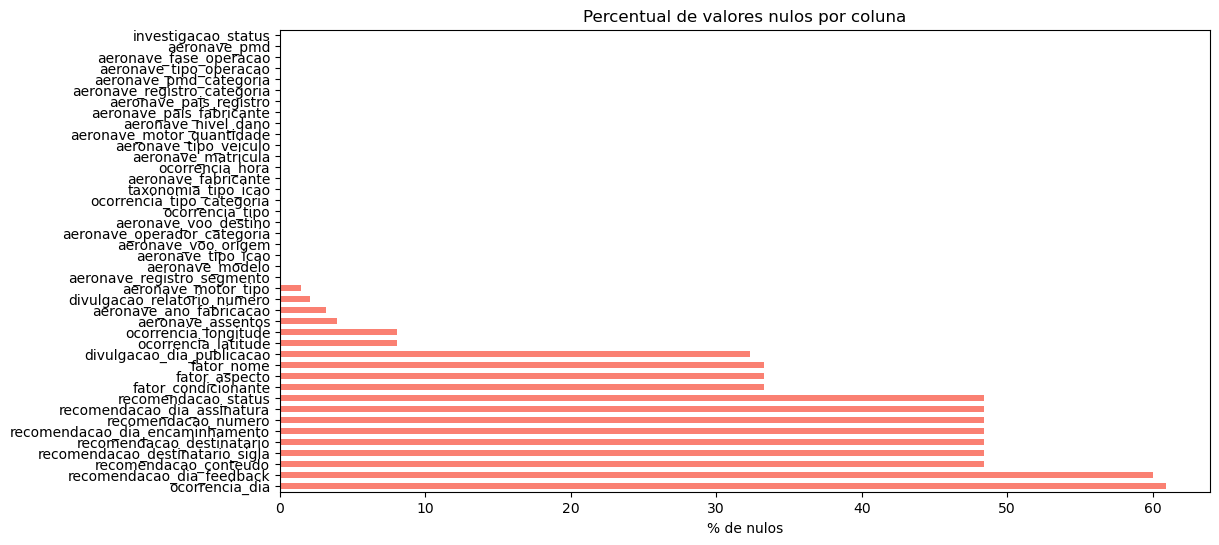

In [16]:
'''
Observa-se 13 variáveis com alta presença de valores nulos (maior que 30%).
'''

# Verificar percentual de nulos por coluna
nulos = df.isnull().mean().sort_values(ascending=False) * 100
print(nulos[nulos > 0])  # Exibir apenas colunas com nulos

# Visualização com gráfico de barras
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
nulos[nulos > 0].plot(kind='barh', color='salmon')
plt.title('Percentual de valores nulos por coluna')
plt.xlabel('% de nulos')
plt.show()

# Tratamento dos Valores Nulos

In [17]:
'''
Tratamento dos valores nulos

'''

# Recomendação
df['recomendacao_status'] = df['recomendacao_status'].fillna('SEM RECOMENDAÇÃO')
df['recomendacao_conteudo'] = df['recomendacao_conteudo'].fillna('SEM RECOMENDAÇÃO')
df['recomendacao_dia_assinatura'] = pd.to_datetime(df['recomendacao_dia_assinatura'], errors='coerce')
df['recomendacao_dia_assinatura'] = df['recomendacao_dia_assinatura'].fillna(pd.NaT)

# Fatores
df['fator_area'] = df['fator_area'].fillna('NÃO IDENTIFICADO')
df['fator_nome'] = df['fator_nome'].fillna('NÃO IDENTIFICADO')

# Latitude/Longitude
df['ocorrencia_latitude'] = df['ocorrencia_latitude'].fillna('NÃO INFORMADO')
df['ocorrencia_longitude'] = df['ocorrencia_longitude'].fillna('NÃO INFORMADO')

# Numéricos
df['aeronave_assentos'] = df['aeronave_assentos'].fillna(df['aeronave_assentos'].median())
df['aeronave_ano_fabricacao'] = df['aeronave_ano_fabricacao'].fillna(df['aeronave_ano_fabricacao'].median())

# Categóricos leves
df.fillna({'aeronave_motor_tipo': 'NÃO INFORMADO',
           'aeronave_modelo': 'NÃO INFORMADO',
           'aeronave_tipo_icao': 'NÃO INFORMADO',
           'aeronave_voo_origem': 'NÃO INFORMADO',
           'aeronave_voo_destino': 'NÃO INFORMADO'}, inplace=True)

In [18]:
# Verificar se ainda existem nulos
nulos_pos_tratamento = df.isnull().sum()
print(nulos_pos_tratamento[nulos_pos_tratamento > 0])


ocorrencia_dia                     21278
ocorrencia_hora                        2
investigacao_status                    1
divulgacao_relatorio_numero          716
divulgacao_dia_publicacao          11290
aeronave_matricula                     1
aeronave_operador_categoria            9
aeronave_tipo_veiculo                  1
aeronave_fabricante                    5
aeronave_motor_quantidade              1
aeronave_pmd                           1
aeronave_pmd_categoria                 1
aeronave_pais_fabricante               1
aeronave_pais_registro                 1
aeronave_registro_categoria            1
aeronave_registro_segmento            25
aeronave_fase_operacao                 1
aeronave_tipo_operacao                 1
aeronave_nivel_dano                    1
fator_aspecto                      11621
fator_condicionante                11621
recomendacao_numero                16904
recomendacao_dia_assinatura        16904
recomendacao_dia_encaminhamento    16904
recomendacao_dia

# Verificação e Tratamento dos Outliers

In [20]:
'''
Criação de tabela com as quantidade e porcentagens de Outliers
'''

# Selecionar apenas colunas numéricas
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Criar dicionários para armazenar resultados
outlier_qtd = {}
outlier_pct = {}

# Loop por coluna
for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    
    outlier_qtd[col] = outliers.shape[0]
    outlier_pct[col] = 100 * outliers.shape[0] / df.shape[0]

# Criar DataFrame com os resultados
outlier_df = pd.DataFrame({
    'Quantidade de Outliers': pd.Series(outlier_qtd),
    'Percentual (%)': pd.Series(outlier_pct).round(2)
}).sort_values(by='Percentual (%)', ascending=False)

# Exibir
print(outlier_df)

                            Quantidade de Outliers  Percentual (%)
aeronave_pmd                                  7586           21.71
aeronave_pmd_categoria                        7586           21.71
aeronave_assentos                             6454           18.47
aeronave_fatalidades_total                    5308           15.19
total_recomendacoes                           4217           12.07
aeronave_ano_fabricacao                       1694            4.85
total_aeronaves_envolvidas                     936            2.68
codigo_ocorrencia2                               0            0.00
codigo_ocorrencia1                               0            0.00
codigo_ocorrencia                                0            0.00
codigo_ocorrencia3                               0            0.00


In [21]:
'''
Vamos criar um dataframe com o tratamento dos Outliers.
'''
# Criar cópia do dataframe original
df_tratado = df.copy()

# Função de winsorização leve
def winsorizar(coluna, limite=0.01):
    lower = df_tratado[coluna].quantile(limite)
    upper = df_tratado[coluna].quantile(1 - limite)
    df_tratado[coluna] = np.clip(df_tratado[coluna], lower, upper)

# Aplicar winsorização nas variáveis com maior percentual de outliers
winsorizar('aeronave_pmd')
winsorizar('aeronave_pmd_categoria')
winsorizar('aeronave_assentos')
winsorizar('aeronave_fatalidades_total')
winsorizar('total_recomendacoes')

# Criar variáveis log-transformadas
df_tratado['log_assentos'] = np.log1p(df_tratado['aeronave_assentos'])
df_tratado['log_pmd'] = np.log1p(df_tratado['aeronave_pmd'])
df_tratado['log_fatalidades'] = np.log1p(df_tratado['aeronave_fatalidades_total'])

# Criar categorias fuzzy para porte da aeronave
def classificar_assentos(valor):
    if valor <= 4:
        return 'PEQUENO PORTE'
    elif valor <= 20:
        return 'MÉDIO PORTE'
    else:
        return 'GRANDE PORTE'

df_tratado['porte_aeronave'] = df_tratado['aeronave_assentos'].apply(classificar_assentos)

# Visualização rápida para validar
print(df_tratado[['aeronave_assentos', 'log_assentos', 'porte_aeronave']].head())

   aeronave_assentos  log_assentos porte_aeronave
0                0.0      0.000000  PEQUENO PORTE
1                6.0      1.945910    MÉDIO PORTE
2                6.0      1.945910    MÉDIO PORTE
3                0.0      0.000000  PEQUENO PORTE
4              184.0      5.220356   GRANDE PORTE


# Visualização dos Dados

In [22]:
'''
Resumo das Variáveis Numéricas
'''

# Resumo estatístico das variáveis numéricas
resumo_numerico = df.select_dtypes(include=['int64', 'float64']).describe().T
resumo_numerico['missing (%)'] = df[resumo_numerico.index].isnull().mean() * 100
resumo_numerico = resumo_numerico[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'missing (%)']]
print(resumo_numerico)

                              count          mean           std      min  \
codigo_ocorrencia           34939.0  55907.091645  19953.871432  28256.0   
codigo_ocorrencia1          34939.0  55907.091645  19953.871432  28256.0   
codigo_ocorrencia2          34939.0  55907.091645  19953.871432  28256.0   
codigo_ocorrencia3          34939.0  55907.091645  19953.871432  28256.0   
total_recomendacoes         34939.0      7.854632     17.544072      0.0   
total_aeronaves_envolvidas  34939.0      1.027448      0.169238      0.0   
aeronave_pmd                34938.0  19220.780754  37301.707922      0.0   
aeronave_pmd_categoria      34938.0  19220.780754  37301.707922      0.0   
aeronave_assentos           34939.0     33.748447     63.164571      0.0   
aeronave_ano_fabricacao     34939.0   1896.664816    427.873426      0.0   
aeronave_fatalidades_total  34939.0     10.060849     41.222312      0.0   

                                25%      50%      75%       max  missing (%)  
codigo_o

In [23]:
'''
Resumo das variáveis Categóricas
'''

# Resumo das variáveis categóricas
resumo_categorico = pd.DataFrame({
    'Tipo': df.select_dtypes(include='object').dtypes,
    'Valores únicos': df.select_dtypes(include='object').nunique(),
    'Mais frequente': df.select_dtypes(include='object').mode().iloc[0],
    'Frequência': df.select_dtypes(include='object').apply(lambda x: x.value_counts().iloc[0]),
    'Missing (%)': df.select_dtypes(include='object').isnull().mean() * 100
})
print(resumo_categorico.sort_values(by='Missing (%)', ascending=False))

                                   Tipo  Valores únicos  \
recomendacao_dia_feedback        object             709   
recomendacao_destinatario        object             178   
recomendacao_numero              object            2298   
recomendacao_dia_encaminhamento  object             344   
recomendacao_destinatario_sigla  object             178   
fator_condicionante              object               7   
fator_aspecto                    object              11   
divulgacao_dia_publicacao        object             351   
divulgacao_relatorio_numero      object            2902   
aeronave_registro_segmento       object              13   
aeronave_operador_categoria      object              12   
taxonomia_tipo_icao              object              36   
ocorrencia_tipo                  object              86   
ocorrencia_tipo_categoria        object              86   
aeronave_fabricante              object             347   
ocorrencia_hora                  object            1255 

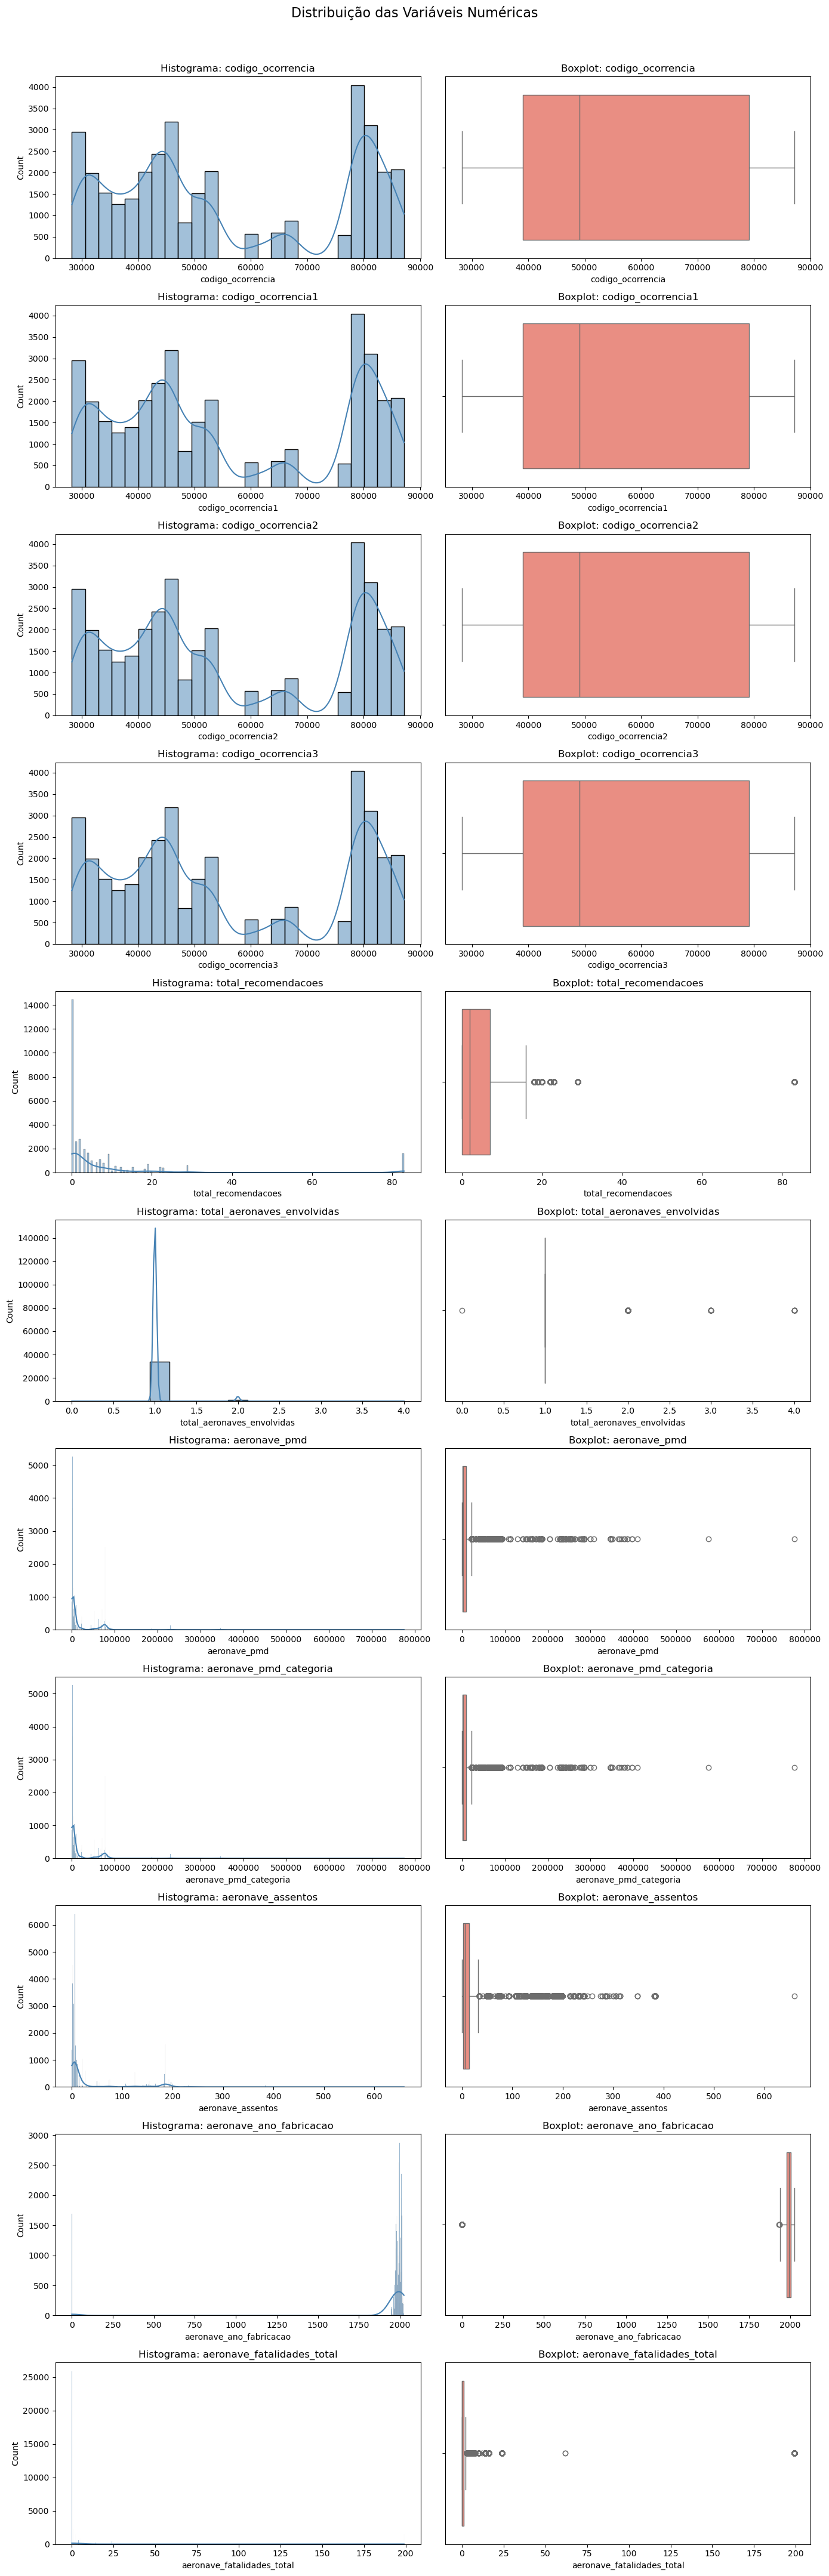

In [24]:
'''
Visualização das Variáveis Numéricas

'''


import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar variáveis numéricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Criar múltiplos gráficos
fig, axes = plt.subplots(nrows=len(numericas), ncols=2, figsize=(14, 4 * len(numericas)))
fig.suptitle('Distribuição das Variáveis Numéricas', fontsize=16)

for i, col in enumerate(numericas):
    # Histograma
    sns.histplot(df[col], ax=axes[i, 0], kde=True, color='steelblue')
    axes[i, 0].set_title(f'Histograma: {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Boxplot: {col}')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

C:\Users\FelipePedrosodeLimaB\AppData\Local\Temp\ipykernel_4680\375319123.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
C:\Users\FelipePedrosodeLimaB\AppData\Local\Temp\ipykernel_4680\375319123.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
C:\Users\FelipePedrosodeLimaB\AppData\Local\Temp\ipykernel_4680\375319123.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
C:\Users\FelipePedr

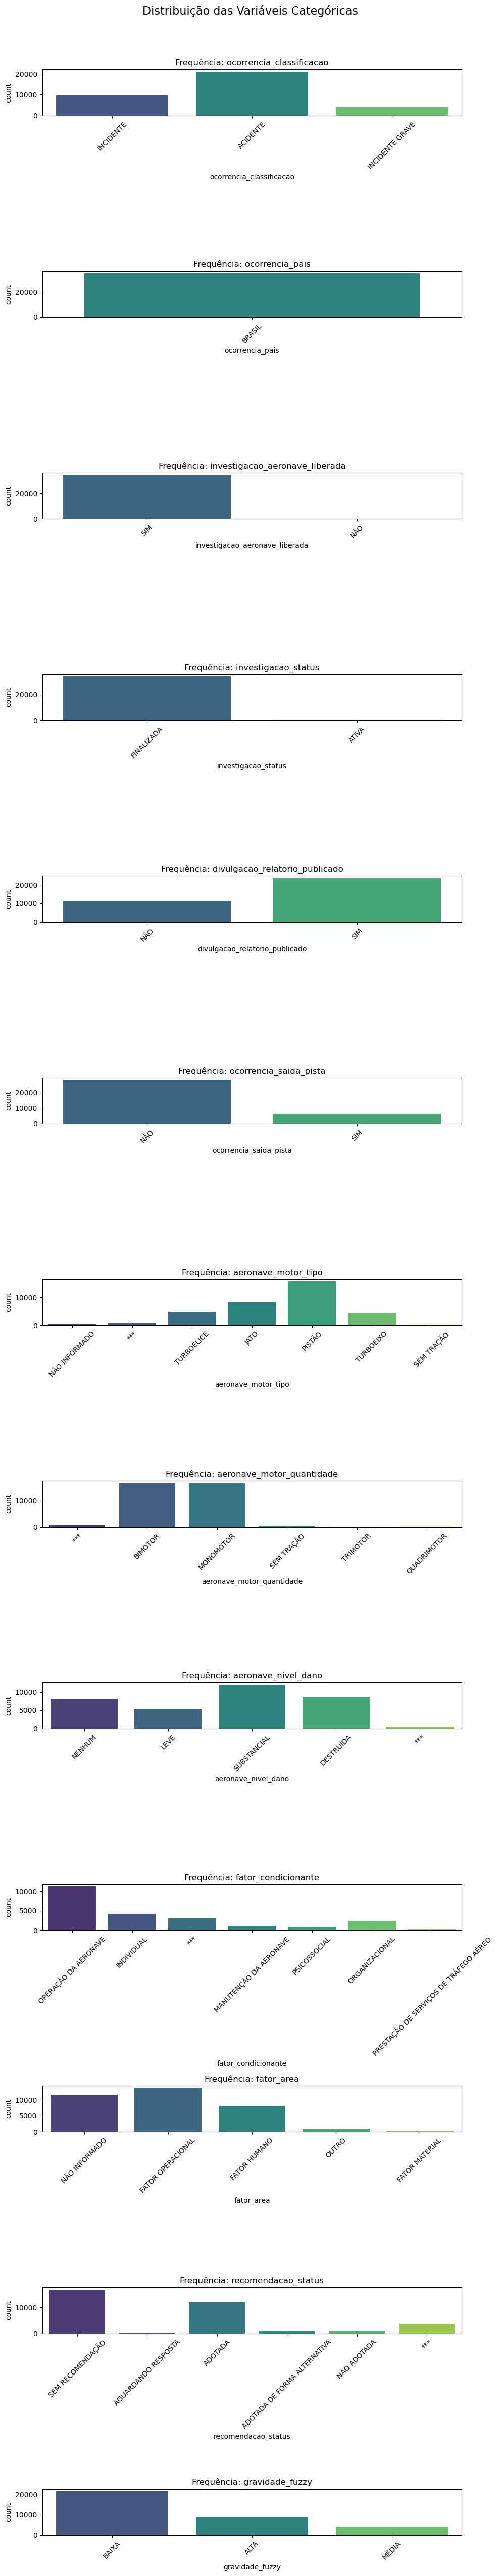

In [25]:
'''
Visualização das Variáveis categóricas
'''
# Selecionar variáveis categóricas com até 10 categorias
categoricas = [col for col in df.select_dtypes(include='object').columns if df[col].nunique() <= 10]

# Criar múltiplos gráficos
fig, axes = plt.subplots(nrows=len(categoricas), ncols=1, figsize=(10, 4 * len(categoricas)))
fig.suptitle('Distribuição das Variáveis Categóricas', fontsize=16)

for i, col in enumerate(categoricas):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frequência: {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Correlações entre as Variáveis

aeronave_fatalidades_total    1.000000
total_recomendacoes           0.945024
log_fatalidades               0.868795
aeronave_assentos             0.536987
log_assentos                  0.443186
aeronave_pmd                  0.385863
aeronave_pmd_categoria        0.385863
log_pmd                       0.330663
aeronave_ano_fabricacao       0.056750
total_aeronaves_envolvidas   -0.039404
codigo_ocorrencia2           -0.302105
codigo_ocorrencia3           -0.302105
codigo_ocorrencia            -0.302105
codigo_ocorrencia1           -0.302105
Name: aeronave_fatalidades_total, dtype: float64


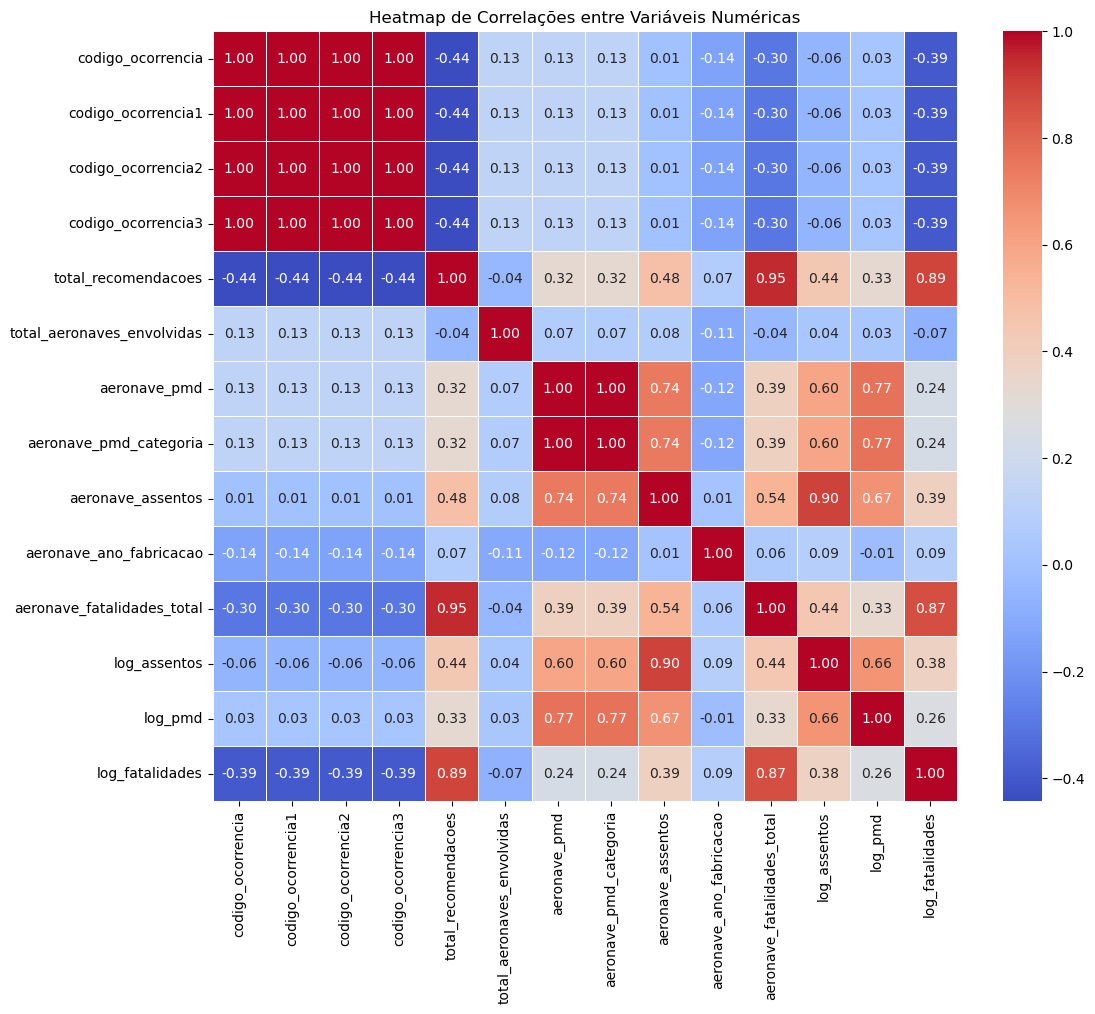

In [26]:
# Selecionar apenas variáveis numéricas
numericas = df_tratado.select_dtypes(include=['int64', 'float64'])

# Gerar matriz de correlação
correlacoes = numericas.corr()

# Exibir tabela ordenada por correlação com variável alvo (exemplo: 'aeronave_fatalidades_total')
correlacao_com_fatalidades = correlacoes['aeronave_fatalidades_total'].sort_values(ascending=False)
print(correlacao_com_fatalidades)

# Heatmap completo
plt.figure(figsize=(12,10))
sns.heatmap(correlacoes, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap de Correlações entre Variáveis Numéricas')
plt.show()

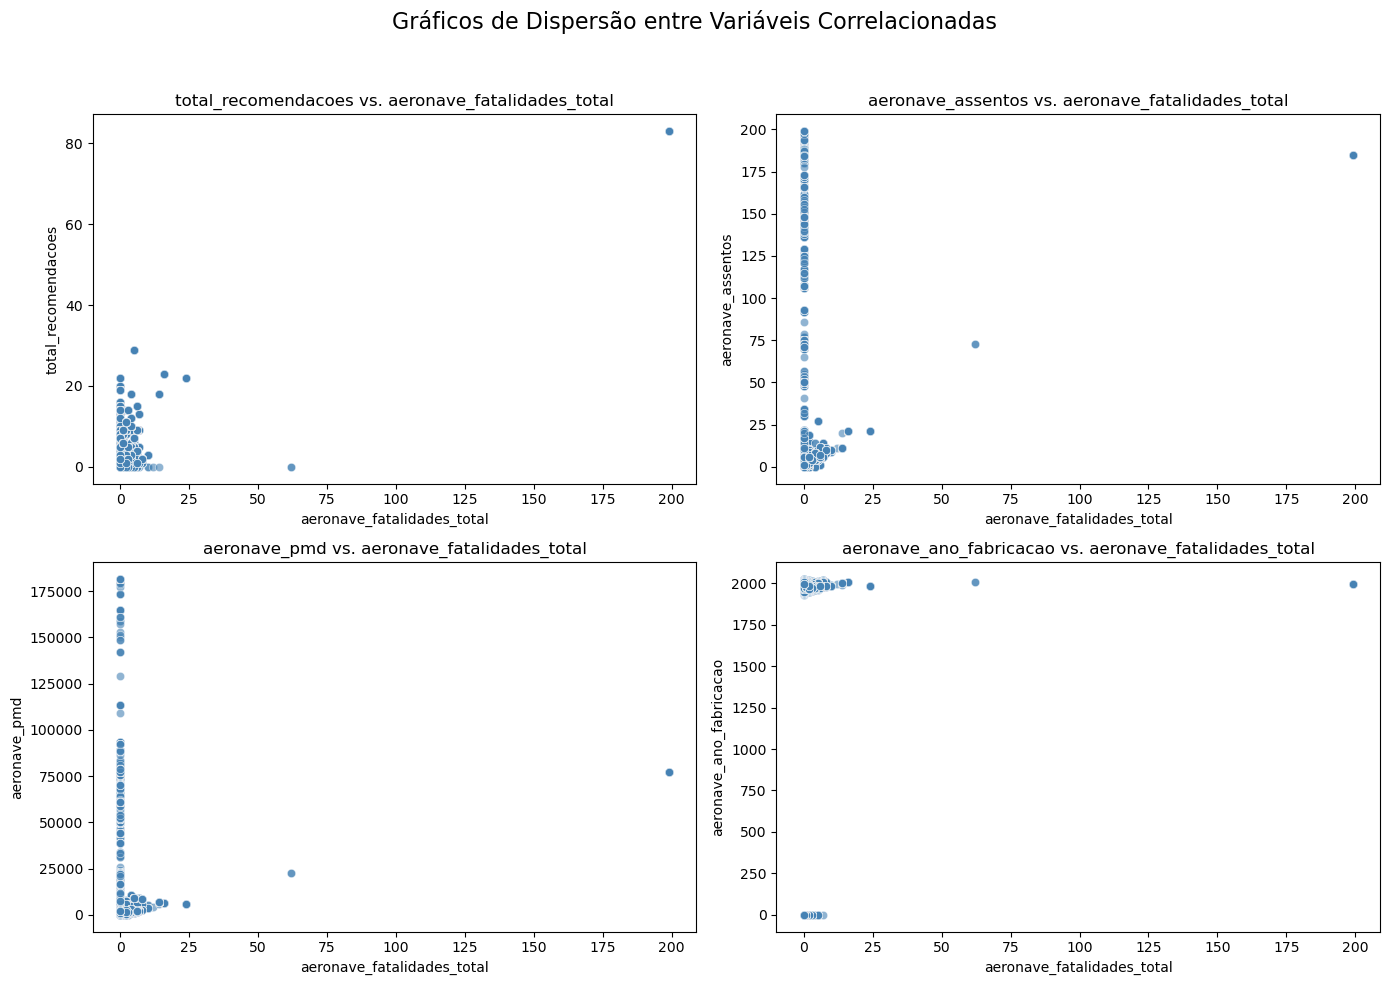

In [27]:
# Lista de pares de variáveis para dispersão
pares = [
    ('aeronave_fatalidades_total', 'total_recomendacoes'),
    ('aeronave_fatalidades_total', 'aeronave_assentos'),
    ('aeronave_fatalidades_total', 'aeronave_pmd'),
    ('aeronave_fatalidades_total', 'aeronave_ano_fabricacao'),
]

# Criar gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
fig.suptitle('Gráficos de Dispersão entre Variáveis Correlacionadas', fontsize=16)

for ax, (x, y) in zip(axes.flat, pares):
    sns.scatterplot(data=df_tratado, x=x, y=y, ax=ax, alpha=0.6, color='steelblue')
    ax.set_title(f'{y} vs. {x}')
    ax.set_xlabel(x)
    ax.set_ylabel(y)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Análise PCA e Estudo de Redução de Dimencionalidade

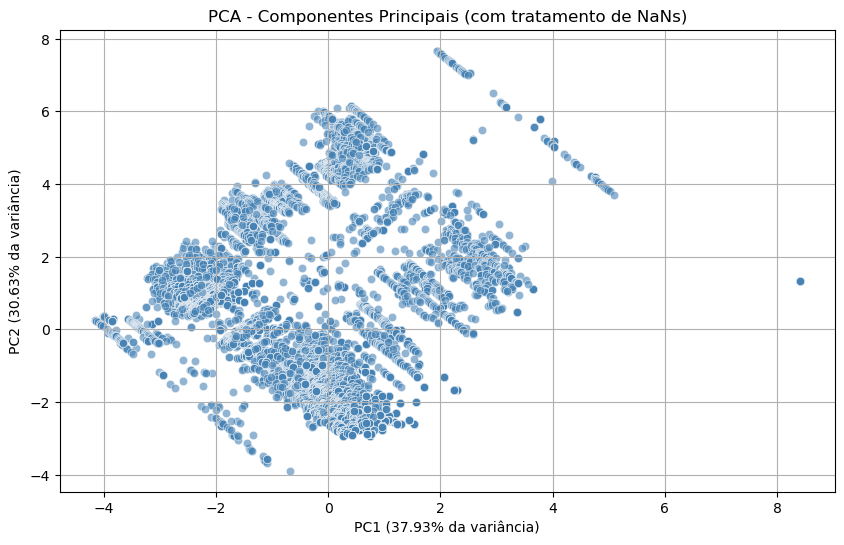

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionar variáveis numéricas do df_tratado
numericas_tratadas = df_tratado.select_dtypes(include=['int64', 'float64'])

# 2. Preencher NaNs com a média
imputer = SimpleImputer(strategy='mean')
numericas_imputadas = imputer.fit_transform(numericas_tratadas)

# 3. Padronizar os dados
scaler = StandardScaler()
numericas_padronizadas = scaler.fit_transform(numericas_imputadas)

# 4. Aplicar PCA
pca = PCA(n_components=2)
componentes = pca.fit_transform(numericas_padronizadas)

# 5. Criar DataFrame com os componentes
df_pca = pd.DataFrame(componentes, columns=['PC1', 'PC2'])

# 6. Visualizar os componentes
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.6, color='steelblue')
plt.title('PCA - Componentes Principais (com tratamento de NaNs)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% da variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% da variância)')
plt.grid(True)
plt.show()

In [29]:
'''
Variância
'''
print("Variância explicada por componente:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")

Variância explicada por componente:
PC1: 0.3793
PC2: 0.3063


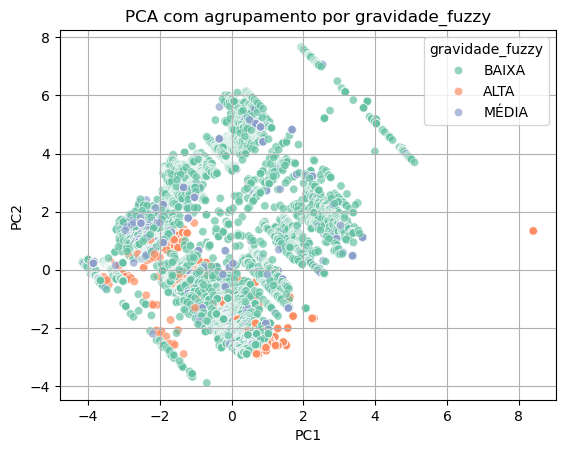

In [30]:
sns.scatterplot(x='PC1', y='PC2', data=df_pca, hue=df_tratado['gravidade_fuzzy'], palette='Set2', alpha=0.7)
plt.title('PCA com agrupamento por gravidade_fuzzy')
plt.grid(True)
plt.show()

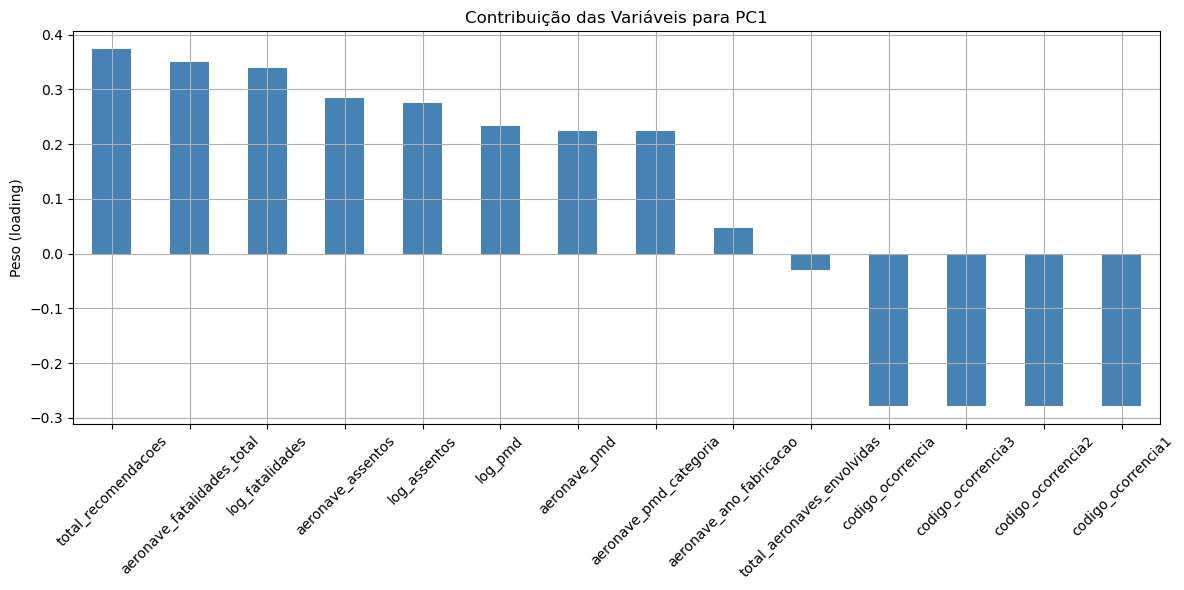

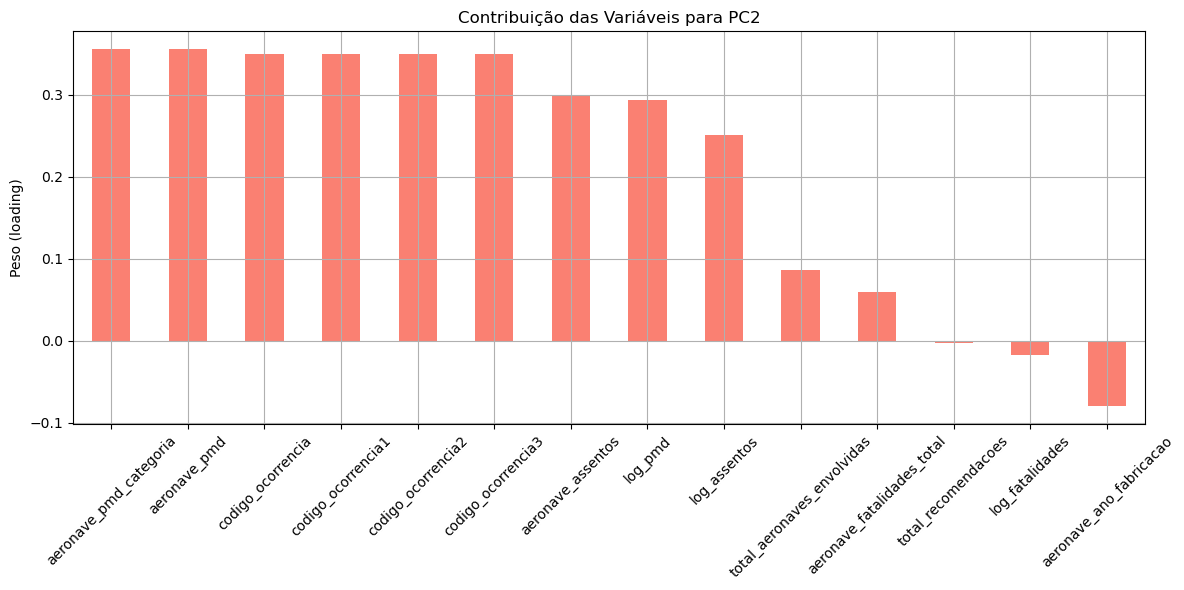

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Obter os nomes das variáveis originais
variaveis = df_tratado.select_dtypes(include=['int64', 'float64']).columns

# 2. Criar DataFrame com os loadings
loadings = pd.DataFrame(pca.components_.T, index=variaveis, columns=['PC1', 'PC2'])

# 3. Visualizar os loadings como gráfico de barras
plt.figure(figsize=(12, 6))
loadings['PC1'].sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Contribuição das Variáveis para PC1')
plt.ylabel('Peso (loading)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
loadings['PC2'].sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Contribuição das Variáveis para PC2')
plt.ylabel('Peso (loading)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

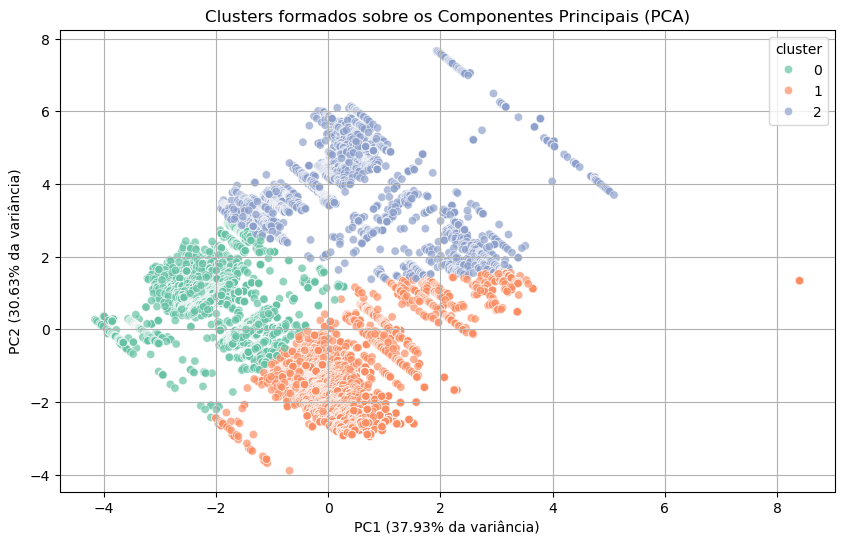

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aplicar KMeans sobre os componentes do PCA
kmeans = KMeans(n_clusters=3, random_state=42)  # você pode testar com 2 a 5 clusters
df_pca['cluster'] = kmeans.fit_predict(df_pca[['PC1', 'PC2']])

# 2. Visualizar os clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='Set2', alpha=0.7)
plt.title('Clusters formados sobre os Componentes Principais (PCA)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% da variância)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% da variância)')
plt.grid(True)
plt.show()

Silhouette Score médio: 0.4907


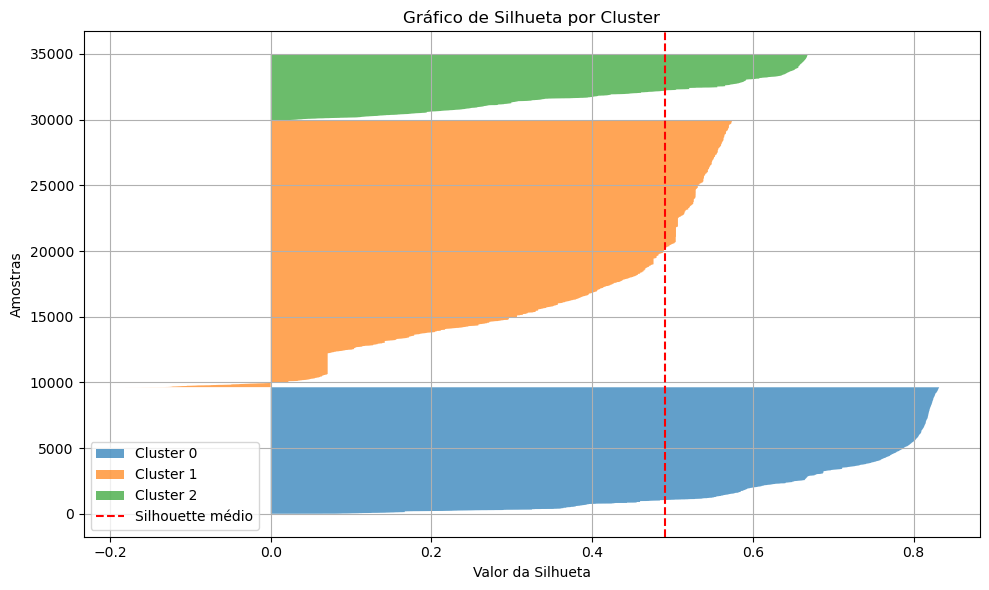

In [33]:
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt
import numpy as np

# 1. Calcular o silhouette score médio
score_medio = silhouette_score(df_pca[['PC1', 'PC2']], df_pca['cluster'])
print(f'Silhouette Score médio: {score_medio:.4f}')

# 2. Calcular os valores individuais
valores_silhueta = silhouette_samples(df_pca[['PC1', 'PC2']], df_pca['cluster'])

# 3. Plotar o gráfico de silhueta
plt.figure(figsize=(10, 6))
y_lower = 10
n_clusters = df_pca['cluster'].nunique()
for i in range(n_clusters):
    # Selecionar valores do cluster i
    valores_i = valores_silhueta[df_pca['cluster'] == i]
    valores_i.sort()
    tamanho_i = len(valores_i)
    y_upper = y_lower + tamanho_i

    # Cor e preenchimento
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_i, alpha=0.7, label=f'Cluster {i}')
    y_lower = y_upper + 10  # espaço entre clusters

# Linha do score médio
plt.axvline(x=score_medio, color='red', linestyle='--', label='Silhouette médio')

plt.title('Gráfico de Silhueta por Cluster')
plt.xlabel('Valor da Silhueta')
plt.ylabel('Amostras')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Aplicação de Feature Importance para entendimento das variáveis mais importantes

In [34]:
'''
Reduzir algumas variáveis de identificação

'''

variaveis_remover = [
    'codigo_ocorrencia', 'codigo_ocorrencia1', 'codigo_ocorrencia2',
    'codigo_ocorrencia3', 'codigo_ocorrencia4',
    'ocorrencia_latitude', 'ocorrencia_longitude',
    'ocorrencia_cidade', 'ocorrencia_pais'
]

df_modelagem = df_tratado.drop(columns=variaveis_remover)

In [35]:
'''
Codificar variáveis categóricas
'''

df_modelagem = df_tratado.drop(columns=variaveis_remover)

# Certifique-se de que 'gravidade_fuzzy' está presente
df_modelagem_encoded = pd.get_dummies(df_modelagem, drop_first=True)

In [36]:
y = df_modelagem['gravidade_fuzzy']
X = df_modelagem_encoded.copy()

# X: todas as variáveis codificadas
X = df_modelagem_encoded.copy()

# y: variável alvo original, ainda presente no df_modelagem
y = df_modelagem['gravidade_fuzzy']
print(y.value_counts())



gravidade_fuzzy
BAIXA    21719
ALTA      9057
MÉDIA     4163
Name: count, dtype: int64


In [37]:
from sklearn.preprocessing import LabelEncoder

# Criar codificador
le = LabelEncoder()

# Aplicar no y
y_encoded = le.fit_transform(y)

# Verificar mapeamento
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'ALTA': np.int64(0), 'BAIXA': np.int64(1), 'MÉDIA': np.int64(2)}


In [39]:
X = X.astype({col: 'int64' for col in X.select_dtypes(include='bool').columns})
for col in X.select_dtypes(include='datetime64').columns:
    X[col + '_year'] = X[col].dt.year
    X[col + '_month'] = X[col].dt.month
    X[col + '_day'] = X[col].dt.day

# Remover original
X = X.drop(columns=X.select_dtypes(include='datetime64').columns)


C:\Users\FelipePedrosodeLimaB\AppData\Local\Temp\ipykernel_4680\642875880.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col + '_year'] = X[col].dt.year
C:\Users\FelipePedrosodeLimaB\AppData\Local\Temp\ipykernel_4680\642875880.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[col + '_month'] = X[col].dt.month
C:\Users\FelipePedrosodeLimaB\AppData\Local\Temp\ipykernel_4680\642875880.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor

In [41]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X, y_encoded)

RandomForestClassifier(random_state=42)

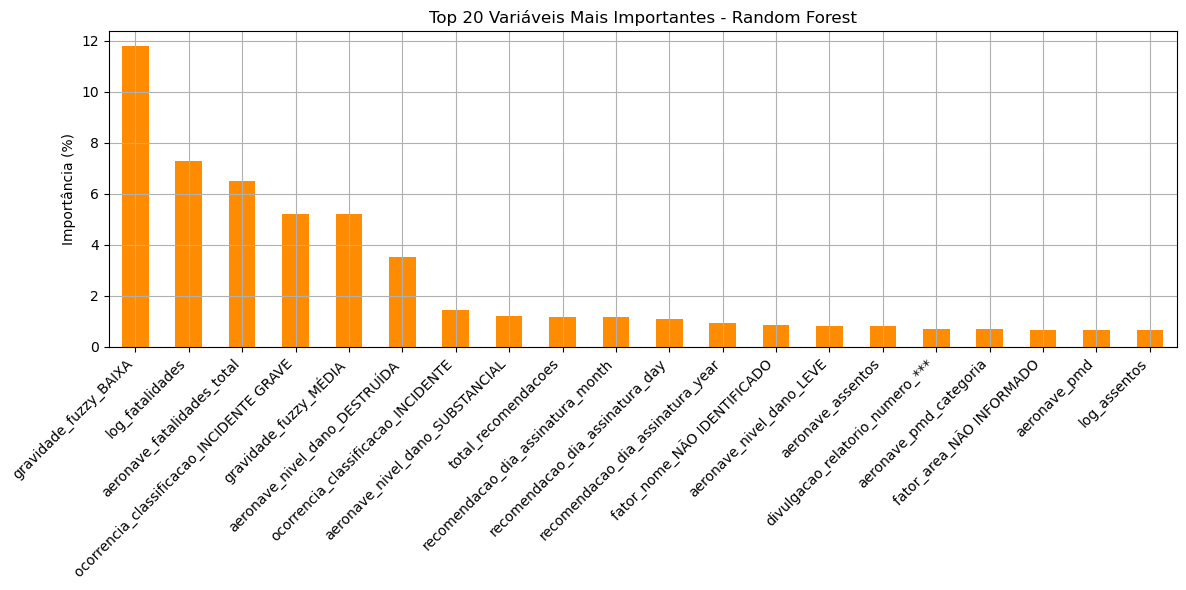

                                    Variável  Importância (%)
0                      gravidade_fuzzy_BAIXA            11.78
1                            log_fatalidades             7.29
2                 aeronave_fatalidades_total             6.51
3   ocorrencia_classificacao_INCIDENTE GRAVE             5.23
4                      gravidade_fuzzy_MÉDIA             5.20
5              aeronave_nivel_dano_DESTRUÍDA             3.53
6         ocorrencia_classificacao_INCIDENTE             1.46
7            aeronave_nivel_dano_SUBSTANCIAL             1.22
8                        total_recomendacoes             1.17
9          recomendacao_dia_assinatura_month             1.16
10           recomendacao_dia_assinatura_day             1.10
11          recomendacao_dia_assinatura_year             0.96
12               fator_nome_NÃO IDENTIFICADO             0.86
13                  aeronave_nivel_dano_LEVE             0.84
14                         aeronave_assentos             0.83
15      

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrair importâncias
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)

# 2. Calcular porcentagem
importancias_percentuais = (importancias_ordenadas / importancias_ordenadas.sum()) * 100
tabela_importancia = pd.DataFrame({
    'Variável': importancias_percentuais.index,
    'Importância (%)': importancias_percentuais.values
})

# 3. Visualizar gráfico
plt.figure(figsize=(12, 6))
importancias_percentuais.head(20).plot(kind='bar', color='darkorange')
plt.title('Top 20 Variáveis Mais Importantes - Random Forest')
plt.ylabel('Importância (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Exibir tabela
print(tabela_importancia.head(20).round(2))

In [43]:
df_tratado.shape

(34939, 64)

In [44]:
df_tratado.to_csv("base_tratada_aviacao_v1.csv")